<a href="https://colab.research.google.com/github/ticiAngelucci/GuiaLaboratorioQuantum/blob/main/modulo3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El "Quantum Sandbox": Tu Laboratorio Visual

Antes de escribir una sola línea de código en Python, utilizaremos la herramienta interactiva de QHub para desarrollar la intuición física.

Instrucciones de uso:

    Ingresá en el siguiente enlace: https://www.qhubperu.com/aprendizaje/modulo4

    Una vez en la página, hacé scroll hacia abajo hasta encontrar la sección titulada: "TU PRIMER CIRCUITO CUÁNTICO !".

    Utilizá el editor visual allí presente para los desafíos de cada módulo.

Acto 0:Decoherencia y Procesos Estocásticos

"La línea de base ideal."
El simulador visual representa un sistema cuántico ideal (sin ruido).

    Construye el circuito que definiste en tu notebook de Python (donde luego aplicarás ruido).

    Utiliza el sandbox para confirmar que, en condiciones ideales, tu circuito hace exactamente lo que predice tu matemática. Luego, compáralo con los resultados de tu código en Colab: ¿cuánta "información" o "probabilidad" se pierde al pasar de este simulador ideal a tu entorno de ruido real?

Ahora seguimos con el codigo:

In [ ]:
#Instalar Qiskit en el notebook
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00


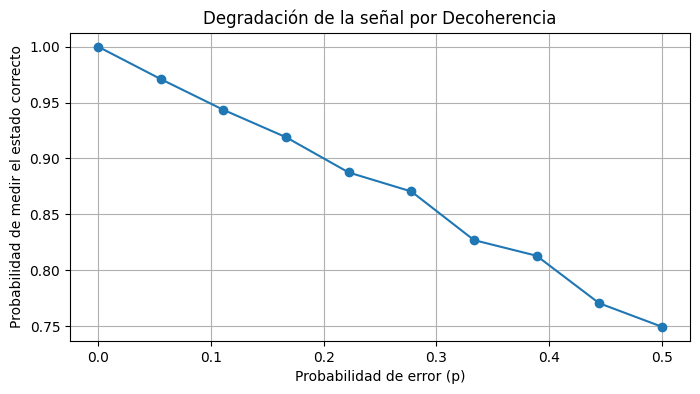

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import matplotlib.pyplot as plt

# 1. Definimos un estado puro inicial: |1>
qc = QuantumCircuit(1)
qc.x(0)
qc.measure_all()

# 2. Creamos un Modelo de Ruido (Proceso Estocástico)
# 'depolarizing_error' modela el ruido donde el qubit pierde su estado
# prob: probabilidad de que el qubit se corrompa en cada gate
def obtener_resultados_con_ruido(prob_error):
    noise_model = NoiseModel()
    error = depolarizing_error(prob_error, 1)
    noise_model.add_all_qubit_quantum_error(error, ['x'])

    sim = AerSimulator(noise_model=noise_model)
    job = sim.run(transpile(qc, sim), shots=2000)
    return job.result().get_counts()

# 3. Análisis de la degradación (Evolución temporal del error)
probabilidades_error = np.linspace(0, 0.5, 10)
fidelidad = [] # Probabilidad de medir el estado correcto '1'

for p in probabilidades_error:
    counts = obtener_resultados_con_ruido(p)
    # Fidelidad = (veces que salió 1) / total
    fidelidad.append(counts.get('1', 0) / 2000)

plt.figure(figsize=(8,4))
plt.plot(probabilidades_error, fidelidad, 'o-')
plt.title("Degradación de la señal por Decoherencia")
plt.xlabel("Probabilidad de error (p)")
plt.ylabel("Probabilidad de medir el estado correcto")
plt.grid(True)
plt.show()

Sección de Práctica: Desafíos de Laboratorio

Desafío 1:La frontera de la Entropía Máxima

Observa la curva de degradación que obtuviste en el laboratorio. Nota que cuando la probabilidad de error (p) alcanza 0.5, la fidelidad (tu capacidad de medir el estado correcto) cae a 0.5, lo cual es el resultado de tirar una moneda honesta.

    Explica matemáticamente qué le sucede a la matriz densidad del qubit en ese punto. ¿Por qué el azar deja de ser una "perturbación" para convertirse en la descripción dominante del sistema? (Pista: investiga el concepto de estado de máxima mezcla).
Desafío 2:Modelado del Ruido: PSD y 1/f

En nuestro código, utilizamos ruido blanco (depolarizing), cuya Densidad Espectral de Potencia (PSD), Sxx​(ω), es plana (constante para todas las frecuencias). Sin embargo, los qubits superconductores reales sufren principalmente de ruido de baja frecuencia o "ruido rosa".

    Si el ruido del entorno tuviera una PSD con una forma Sxx​(ω)∝ω1​, ¿qué implicaciones tendría esto para la coherencia de nuestro qubit en comparación con el ruido blanco? ¿Cómo afectarían estos picos en bajas frecuencias a la estabilidad de la superposición a largo plazo?
Desafío 3:Estacionariedad y Cadenas de Markov

Si definimos nuestro qubit como un sistema de dos estados {∣0⟩,∣1⟩} y una matriz de transición P donde, en cada unidad de tiempo, existe una probabilidad p de sufrir un bit-flip, tenemos la siguiente matriz

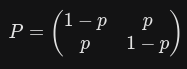

    Utilizando la teoría de procesos estocásticos, calcula la distribución estacionaria π=(π0​,π1​) tal que πP=π. Si dejamos correr la cadena durante N→∞ pasos, ¿a qué estado llegará el sistema? ¿Cómo se relaciona este resultado teórico con la pérdida de información que observamos en la gráfica de degradación?
